# Task 2-2: Wine Dataset Classification

Testing different preprocessing and network configs.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


In [2]:
wine = load_wine()
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)}, Test: {len(X_test)}, Features: {X.shape[1]}')

Train: 142, Test: 36, Features: 13


In [3]:
def preprocess(X_tr, X_te, method='standard'):
    if method == 'standard': scaler = StandardScaler()
    elif method == 'minmax': scaler = MinMaxScaler()
    elif method == 'robust': scaler = RobustScaler()
    else: return X_tr, X_te
    return scaler.fit_transform(X_tr), scaler.transform(X_te)

def make_loaders(X_tr, X_te, y_tr, y_te, bs=32):
    tr = DataLoader(TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.long)), batch_size=bs, shuffle=True)
    te = DataLoader(TensorDataset(torch.tensor(X_te, dtype=torch.float32), torch.tensor(y_te, dtype=torch.long)), batch_size=bs)
    return tr, te

In [4]:
class MLP(nn.Module):
    def __init__(self, inp, hidden, out, drop=0.0, bn=False):
        super().__init__()
        layers = []
        prev = inp
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            if bn: layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if drop > 0: layers.append(nn.Dropout(drop))
            prev = h
        layers.append(nn.Linear(prev, out))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

In [5]:
def run_exp(cfg, epochs=150):
    X_tr, X_te = preprocess(X_train, X_test, cfg.get('scaler', 'standard'))
    tr_loader, te_loader = make_loaders(X_tr, X_te, y_train, y_test)
    model = MLP(X_tr.shape[1], cfg.get('hidden', [64,32]), 3, cfg.get('drop',0), cfg.get('bn',False)).to(device)
    criterion = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=cfg.get('lr', 0.001))
    for _ in range(epochs):
        model.train()
        for X, y in tr_loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            opt.step()
    model.eval()
    correct, total = 0, 0
    preds, labels = [], []
    with torch.no_grad():
        for X, y in te_loader:
            X, y = X.to(device), y.to(device)
            p = model(X).argmax(1)
            correct += (p == y).sum().item()
            total += y.size(0)
            preds.extend(p.cpu().numpy())
            labels.extend(y.cpu().numpy())
    return 100*correct/total, preds, labels

In [6]:
experiments = [
    {'name': 'No preproc', 'scaler': 'none'},
    {'name': 'Standard', 'scaler': 'standard'},
    {'name': 'MinMax', 'scaler': 'minmax'},
    {'name': 'Robust', 'scaler': 'robust'},
    {'name': 'Shallow', 'hidden': [32]},
    {'name': 'Deep', 'hidden': [128, 64, 32]},
    {'name': 'Dropout', 'drop': 0.3},
    {'name': 'BatchNorm', 'bn': True},
    {'name': 'Low LR', 'lr': 0.0001},
]

results = []
best_acc, best_preds, best_labels = 0, None, None
for exp in experiments:
    acc, preds, labels = run_exp(exp)
    results.append({'Exp': exp['name'], 'Acc (%)': round(acc, 1)})
    if acc > best_acc: best_acc, best_preds, best_labels = acc, preds, labels
    print(f"{exp['name']}: {acc:.1f}%")

No preproc: 94.4%
Standard: 97.2%
MinMax: 97.2%
Robust: 97.2%
Shallow: 97.2%
Deep: 97.2%
Dropout: 94.4%
BatchNorm: 97.2%
Low LR: 94.4%


In [7]:
df = pd.DataFrame(results)
print('\n=== Results ===')
print(df.to_string(index=False))



=== Results ===
       Exp  Acc (%)
No preproc     94.4
  Standard     97.2
    MinMax     97.2
    Robust     97.2
   Shallow     97.2
      Deep     97.2
   Dropout     94.4
 BatchNorm     97.2
    Low LR     94.4


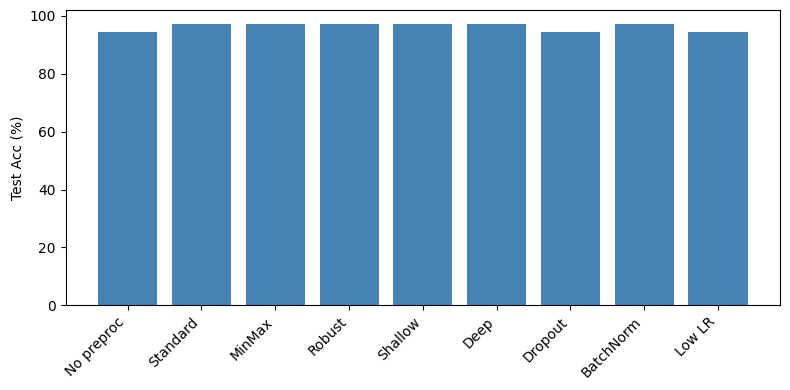

In [8]:
plt.figure(figsize=(8, 4))
plt.bar(df['Exp'], df['Acc (%)'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Test Acc (%)')
plt.tight_layout()
plt.show()

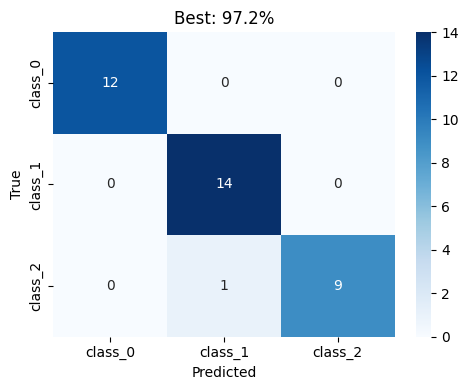

In [9]:
cm = confusion_matrix(best_labels, best_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Best: {best_acc:.1f}%')
plt.tight_layout()
plt.show()

## Summary

- Preprocessing is important - no scaling gives bad results
- StandardScaler works well here